## Importing the dataset


In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import os
os.chdir("/content/gdrive/MyDrive/magistrs/data")
!ls

 missing_fields_all_records.png      notated-music-dataset-grouped.csv
 missing_fields_sample_records.png  'Untitled document.gdoc'
 notated-music-dataset.csv


## Providing basic information on the data set


In [3]:
import pandas as pd
df = pd.read_csv('notated-music-dataset.csv',sep=',', low_memory=False)

In [4]:
print("\nNational bibliography of notated music column names\n", df.columns)
print("\nNational bibliography of notated music first five records \n", df.head(5))


National bibliography of notated music column names
 Index(['ierakstu_id', '008', 'language(008)', 'Accompanying matter(008)',
       'Form of item(008)', 'Target audience(008)', 'Music parts(008)',
       'compostion_format(008)', 'music_format(008)',
       'publishing_country(008)',
       ...
       'contained work title (740)', 'contained_work_raw(740)',
       'person related to the series (800)', 'series authority record (830)',
       'resursa saite (856 1)', 'papildmateriāla saite (856 2)',
       'e-resource filter (901)', 'digitalization info (905)',
       'collection (906)', 'creation year (915)'],
      dtype='object', length=164)

National bibliography of notated music first five records 
    ierakstu_id                                       008 language(008)  \
0         7267  030531s2006^^^^lv^sgz^f^^^^^^^^^^^^lav^^       Latvian   
1         7267                                       NaN       Latvian   
2         7267                                       NaN       

In [5]:
print("\nDescription of National bibliography of notated music\n",df.describe().to_markdown())
print("\nNational bibliography of notated music datatypes\n",df.dtypes)


Description of National bibliography of notated music
 |       |      ierakstu_id |   full_year_008 |   Playing_Time(306) |   Number/sequence of the event (611_n) |   creation year (915) |
|:------|-----------------:|----------------:|--------------------:|---------------------------------------:|----------------------:|
| count |  94282           |      94278      |              27     |                               28       |           94278       |
| mean  | 802044           |       1973.58   |            1028.07  |                                8.21429 |            2016.21    |
| std   | 282684           |         41.2401 |             597.281 |                                9.80309 |               5.35823 |
| min   |   7267           |       1652      |             145     |                                1       |            2003       |
| 25%   | 661449           |       1940      |             650     |                                2       |            2013       |
| 50% 

In [6]:
print(df.isnull().sum())

ierakstu_id                          0
008                              76556
language(008)                        4
Accompanying matter(008)             4
Form of item(008)                   30
                                 ...  
papildmateriāla saite (856 2)    93699
e-resource filter (901)          93019
digitalization info (905)        93234
collection (906)                 93820
creation year (915)                  4
Length: 164, dtype: int64


In [7]:
df.isna().sum()

,0
ierakstu_id,0
008,76556
language(008),4
Accompanying matter(008),4
Form of item(008),30
...,...
papildmateriāla saite (856 2),93699
e-resource filter (901),93019
digitalization info (905),93234
collection (906),93820


In [8]:
df.shape

(94282, 164)

In [9]:
#Checking the year column data type
df["full_year_008"].dtype

dtype('float64')

In [10]:
# Renaminig the identification column
df = df.rename(columns={"ierakstu_id": "ID"})

In [11]:
df.columns

Index(['ID', '008', 'language(008)', 'Accompanying matter(008)',
       'Form of item(008)', 'Target audience(008)', 'Music parts(008)',
       'compostion_format(008)', 'music_format(008)',
       'publishing_country(008)',
       ...
       'contained work title (740)', 'contained_work_raw(740)',
       'person related to the series (800)', 'series authority record (830)',
       'resursa saite (856 1)', 'papildmateriāla saite (856 2)',
       'e-resource filter (901)', 'digitalization info (905)',
       'collection (906)', 'creation year (915)'],
      dtype='object', length=164)

In [12]:
# Check how many records are there in the dateset by counting unique ID
df["ID"].nunique()

17726

In [13]:
df_unique = df.drop_duplicates(subset=["ID"])

#Visualizations


In [14]:
import matplotlib.pyplot as plt
import plotly.express as px

# Publications over the full year range

In [15]:
df["full_year_008"].min(), df["full_year_008"].max()


(1652.0, 2025.0)

In [16]:
counts = (
    df_unique.groupby("full_year_008")["ID"]
    .nunique()
    .reset_index(name="n_publications")
)

In [17]:
fig = px.line(
    counts,
    x="full_year_008",
    y="n_publications",
    title="Number of Notated Music Publications per Year (1650–2025)",
    labels={"full_year_008": "Year", "n_publications": "Publications"},
    template="simple_white"
)
fig.update_layout(
    width=2000,
    height=800,
    xaxis=dict(range=[1650, 2050]),
)
fig.show()

## Visualizing the languages used for the publications

In [18]:
df["language(008)"].nunique()

35

In [19]:
lang_counts = (
    df_unique["language(008)"]
    .value_counts()
    .reset_index()
)

In [20]:
lang_counts = lang_counts.rename(columns={"language(008)": "language"})

In [21]:
fig = px.bar(
    lang_counts,
    x="count",
    y="language",
    orientation="h",
    title="Languages in National Bibliography Notated Music Publications"
)
fig.show()

In [22]:
lang_year = (
    df_unique.groupby(["full_year_008", "language(008)"])["ID"]
    .nunique()
    .reset_index(name="count")
)

In [23]:
# Filtering a time period from 1900 till 2025
lang_year_filtered = lang_year[
    (lang_year["full_year_008"] >= 1900) &
    (lang_year["full_year_008"] <= 2025)
]

In [24]:
lang_over_time = lang_year_filtered.pivot(
    index="full_year_008",
    columns="language(008)",
    values="count"
).fillna(0)

In [25]:
fig = px.area(
    lang_year,
    x="full_year_008",
    y="count",
    color="language(008)",
    title="Languages Used in Notated Music Publications Over Time",
)
fig.show()

In [26]:
fig = px.area(
    lang_year,
    x="full_year_008",
    y="count",
    color="language(008)",
    groupnorm="fraction",
    title="Language Composition of Notated Music Publications Over Time (Normalized)",
    labels={
        "full_year_008": "Year",
        "count": "Proportion of Publications",
        "language(008)": "Language"
    }
)

fig.update_layout(
    width=1300,
    height=600,
    legend_title="Language"
)

fig.show()

In [27]:
lang_counts

,language,count
0,Latvian,10737
1,No linguistic content,4005
2,German,1129
3,Russian,627
4,Latin,498
5,English,451
6,French,63
7,Swedish,34
8,Italian,32
9,Estonian,31


In [28]:
lang_counts["percentage"] = (
    lang_counts["count"] / lang_counts["count"].sum() * 100
)

lang_counts

,language,count,percentage
0,Latvian,10737,60.572041
1,No linguistic content,4005,22.593930
2,German,1129,6.369175
3,Russian,627,3.537177
4,Latin,498,2.809432
5,English,451,2.544285
6,French,63,0.355410
7,Swedish,34,0.191809
8,Italian,32,0.180526
9,Estonian,31,0.174884


In [29]:
# Creating a top 10 languages and grouping together smaller used langauges as "Other"
top10_lang = lang_counts.head(10)
other_sum_lang = lang_counts["count"].iloc[10:].sum()
other_row_lang = pd.DataFrame([{"language": "Other", "count": other_sum_lang}])

In [30]:
top10_with_other_lang = pd.concat([top10_lang,other_row_lang], ignore_index=True)
top10_with_other_lang

,language,count,percentage
0,Latvian,10737,60.572041
1,No linguistic content,4005,22.593930
2,German,1129,6.369175
3,Russian,627,3.537177
4,Latin,498,2.809432
5,English,451,2.544285
6,French,63,0.355410
7,Swedish,34,0.191809
8,Italian,32,0.180526
9,Estonian,31,0.174884


In [31]:
fig = px.bar(
    top10_with_other_lang,
    x="count",
    y="language",
    orientation="h",
    title="Top 10 Languages in Notated Music Publications (with 'Other')"
)
fig.show()


In [32]:
lang_counts2 = df_unique["language(008)"].value_counts()
top10_langs = lang_counts2.head(10).index

In [33]:
lang_year = (
    df_unique
    .groupby(["full_year_008", "language(008)"])["ID"]
    .nunique()
    .reset_index(name="count")
)

In [34]:
lang_year["language_group"] = lang_year["language(008)"].where(
    lang_year["language(008)"].isin(top10_langs),
    "Other"
)

In [35]:
lang_year["language_group"].value_counts()

,count
language_group,
Latvian,168
No linguistic content,166
German,133
Russian,128
Other,80
English,59
Latin,55
French,40
Italian,26


In [36]:
lang_year_top = (
    lang_year
    .groupby(["full_year_008", "language_group"])["count"]
    .sum()
    .reset_index()
)

In [37]:
fig = px.area(
    lang_year_top,
    x="full_year_008",
    y="count",
    color="language_group",
    groupnorm="fraction",
    title="Language Composition of Notated Music Publications Over Time (Top 10 + Other, Normalized)",
    labels={
        "full_year_008": "Year",
        "count": "Proportion of Publications",
        "language_group": "Language"
    }
)

fig.update_layout(
    width=1300,
    height=600,
    legend_title="Language"
)

fig.show()

## Publishers

In [38]:
publisher_col = "Name of publisher (260_b_un_2641_b)"

publisher_counts = (
    df_unique[publisher_col]
    .value_counts()
    .reset_index(name="count")
    .rename(columns={"index": "publisher"})
)

publisher_counts

,Name of publisher (260_b_un_2641_b),count
0,Musica Baltica,3923
1,Lettonie,718
2,Carl Blosfeld,595
3,Филармония,578
4,Autora izdevums,507
...,...,...
1408,LPSR TIM Republikāniskais skolotāju kvalifikāc...,1
1409,Jāzepa Mediņa Rīgas Mūzikas vidusskolas atbals...,1
1410,Изданіе кн. маг. Ф.И. Трескиной,1
1411,Изданіе книжнаго магазина В. Меллина и Ко.,1


In [39]:
df_pub = (
    df_unique[[publisher_col, "full_year_008"]]
    .replace({pd.NA: None})
    .dropna()
)

In [40]:
def classify_era(year):
    if year < 1800:
        return "Pre-1800"
    elif 1800 <= year < 1900:
        return "19th century (1800–1900)"
    elif 1900 <= year < 1940:
        return "Early 20th century (1900–1940)"
    elif 1940 <= year < 1990:
        return "Soviet period (1940–1990)"
    else:
        return "Post-1991 (1991–2025)"

In [41]:
df_pub["era"] = df_pub["full_year_008"].apply(classify_era)

In [42]:
pub_era_counts = (
    df_pub
    .groupby(["era", publisher_col])
    .size()
    .reset_index(name="count")
)

In [43]:
# The "n" can be changed to how many publisher are included in the top
N = 30

top_publishers = (
    pub_era_counts.groupby(publisher_col)["count"]
    .sum()
    .sort_values(ascending=False)
    .head(N)
    .index
)

pub_era_top = pub_era_counts[pub_era_counts[publisher_col].isin(top_publishers)]

In [44]:
fig = px.density_heatmap(
    pub_era_top,
    x="era",
    y=publisher_col,
    z="count",
    color_continuous_scale="Blues",
    title=f"Publisher Activity by Historical Period (Top {N} Publishers)",
)

fig.update_layout(
    width=1200,
    height=900,
    xaxis_title="Historical Era",
    yaxis_title="Publisher",
    coloraxis_colorbar_title="Publications",
)

fig.show()

# Visualization about notated music specific fields

## Form of Item

In [45]:
form_counts = (
    df_unique["Form of item(008)"]
    .value_counts(dropna=True)
    .reset_index(name="count")
)
form_counts

,Form of item(008),count
0,No attempt to code,13579
1,Regular print reproduction,2293
2,Electronic,995
3,Braille,793
4,Online,59
5,Microfiche,5


In [46]:
fig = px.bar(
    form_counts,
    x="count",
    y="Form of item(008)",
    orientation="h",
    title="Distribution of Form of Item (MARC 008/23)",
    labels={"count": "Number of Records", "Form of item(008)": "Form"}
)
fig.show()

## Target audience

In [47]:
audience_counts = (
    df_unique["Target audience(008)"]
    .value_counts()
    .reset_index(name="count")
    .rename(columns={"index": "audience"})
)

px.bar(
    audience_counts,
    x="count", y="Target audience(008)",
    orientation="h",
    title="Target Audience Codes in Notated Music (MARC 008/22)"
).show()

## Music Parts

In [48]:
parts_counts = (
    df_unique["Music parts(008)"]
    .value_counts()
    .reset_index(name="count")
)
fig = px.bar(
    parts_counts,
    x="count",
    y="Music parts(008)",
    orientation="h",
    title="Music Parts Information (MARC 008/21)"
)
fig.show()

## Types of musical composition

In [49]:
comp_counts = (
    df_unique["compostion_format(008)"]
    .value_counts()
    .reset_index(name="count")
)

px.bar(
    comp_counts,
    x="count",
    y="compostion_format(008)",
    orientation="h",
    title="All Composition Format Codes (MARC 008/18–19)"
).show()

In [50]:
comp_counts

,compostion_format(008),count
0,unknown,9130
1,Part-song,3467
2,songs,2164
3,Folk music,391
4,Popular music,391
5,Opera,346
6,Waltzes,249
7,Motion picture music,196
8,Studies and exercises,151
9,Multiple forms,142


In [51]:
top10_comp = comp_counts.head(10)

In [52]:
px.bar(
    top10_comp,
    x="count",
    y="compostion_format(008)",
    orientation="h",
    title="Top 10 Composition Format Codes (MARC 008/18–19)"
).show()

In [53]:
last10_comp = comp_counts.tail(10)

In [54]:
px.bar(
   last10_comp,
    x="count",
    y="compostion_format(008)",
    orientation="h",
    title="Last 10 Composition Format Codes (MARC 008/18–19)"
).show()

## Music Format

In [55]:
format_counts = (
    df_unique["music_format(008)"]
    .value_counts()
    .reset_index(name="count")
)

px.bar(
    format_counts,
    x="count",
    y="music_format(008)",
    orientation="h",
    title="Music Format (MARC 008/20)"
).show()

## Publishers + Music format

In [56]:
top_publishers = (
    df_unique[publisher_col]
    .value_counts()
    .head(30)
    .index
)

music_formats = (
    df_unique["music_format(008)"]
    .value_counts()
    .index
)

In [57]:
df_pub_fmt = df_unique[
    df_unique[publisher_col].isin(top_publishers) &
    df_unique["music_format(008)"].isin(music_formats)
]

In [58]:
pub_fmt_counts = (
    df_pub_fmt
    .groupby([publisher_col, "music_format(008)"])["ID"]
    .nunique()
    .reset_index(name="count")
)

In [59]:
fig = px.density_heatmap(
    pub_fmt_counts,
    x="music_format(008)",
    y=publisher_col,
    z="count",
    title="Top 30 Publishers vs. All Music Formats",
    labels={
       "music_format(008)": "Music format (008/20)",
        publisher_col: "Publisher",
        "count": "Number of publications"
    },
    color_continuous_scale="Cividis"
)

fig.update_layout(height=700)
fig.show()

## Publishers + Compostion format


In [60]:
comp_format_col = "compostion_format(008)"

In [61]:
top_comp_formats = (
    df_unique[comp_format_col]
    .value_counts()
    .index
)

In [62]:
df_pub_comp = df_unique[
    df_unique[publisher_col].isin(top_publishers) &
    df_unique[comp_format_col].isin(top_comp_formats)
]

In [63]:
pub_comp_counts = (
    df_pub_comp
    .groupby([publisher_col, comp_format_col])["ID"]
    .nunique()
    .reset_index(name="count")
)

In [64]:
fig = px.density_heatmap(
    pub_comp_counts,
    x=comp_format_col,
    y=publisher_col,
    z="count",
    title="Top 30 Publishers vs. Composition Formats",
    labels={
        comp_format_col: "Composition format (008/18–19)",
        publisher_col: "Publisher",
        "count": "Number of publications"
    },
    color_continuous_scale="Cividis"
)

fig.update_layout(height=800)
fig.show()

## 040 - Cataloging Source

In [65]:
df_unique["Original cataloging agency(040_a)"].value_counts()

,count
Original cataloging agency(040_a),
Latvijas Nacionālā bibliotēka,17557
Latvijas Universitātes bibliotēka,132
Latvijas Universitātes Akadēmiskā bibliotēka,30
Latvijas Biozinātņu un tehnoloģiju universitātes Fundamentālā bibliotēka,5
Valsts aģentūrā Latvijas Medicīnas bibliotēka,2


In [66]:
df_unique["Modifying agency(040_d)"].value_counts()

,count
Modifying agency(040_d),
Latvijas Universitātes Akadēmiskā bibliotēka,2656
Latvijas Universitātes bibliotēka,405
Latvijas Nacionālā bibliotēka,93
Latvijas Kultūras akadēmijas bibliotēka,8
LKA Latvia Culture College,5
Latvijas Biozinātņu un tehnoloģiju universitātes Fundamentālā bibliotēka,3
Latvijas Policijas akadēmija fundamentālā bibliotēka,1
Patentu tehniskā bibliotēka,1


In [67]:
df_unique["RDA(040_e)"].value_counts()

,count
RDA(040_e),
rda,17721


## Top of Original cataloging agency

In [68]:
col_agency = "Original cataloging agency(040_a)"

top_orig = (
    df_unique[col_agency]
    .value_counts()
    .reset_index(name="count")
)

fig = px.bar(
    top_orig,
    x="count",
    y="Original cataloging agency(040_a)",
    orientation="h",
    title="Original Cataloging Agencies (040$a)",
    labels={"agency": "Agency", "count": "Record count"}
)

fig.update_layout(height=500)
fig.show()

## Top of Modifying agency

In [69]:
col_d = "Modifying agency(040_d)"

top_mod = (
    df_unique[col_d]
    .value_counts()
    .reset_index(name="count")
)

fig = px.bar(
    top_mod,
    x="count",
    y="Modifying agency(040_d)",
    orientation="h",
    title="Modifying Agencies (040$d)",
    labels={"agency": "Agency", "count": "Record modifications"}
)

fig.update_layout(height=500)
fig.show()

## Record in RDA standart

In [70]:
col_e = "RDA(040_e)"

rda_counts = (
    df_unique[col_e]
    .fillna("Not specified")
    .value_counts()
    .reset_index(name="count")
)

fig = px.pie(
    rda_counts,
    names="RDA(040_e)",
    values="count",
    title="Use of RDA in Notated Music Records (040$e)",
)

fig.show()

In [71]:
matrix = (
    df_unique
    .groupby([col_agency, col_d])["ID"]
    .nunique()
    .reset_index(name="count")
)

fig = px.density_heatmap(
    matrix,
    x=col_d,
    y=col_agency,
    z="count",
    color_continuous_scale="Cividis",
    title="Original Agency vs. Modifying Agency (040$a × 040$d)",
    labels={
        col_agency: "Original Agency",
        col_d: "Modifying Agency",
        "count": "Records"
    }
)

fig.update_layout(height=700)
fig.show()


## Translated resources languages (041)

###The translated resource language

In [73]:
col_a_lang = "Language code of text/sound track or separate title (041_a)"

lang_a_counts = (
    df[col_a_lang ]
    .value_counts()
    .reset_index(name="count")
)


px.bar(
    lang_a_counts.head(15),
    x="count",
    y="Language code of text/sound track or separate title (041_a)",
    orientation="h",
    title="Top Languages of Translated Notated Music Materials (041$a)",
    labels={"language": "Language code", "count": "Record count"}
).show()


### Language code of librettos(041_e)

In [74]:
col_e_lang = "Language code of librettos(041_e)"

libretto_counts = (
    df[col_e_lang]
    .value_counts()
    .reset_index(name="count")
)

px.bar(
    libretto_counts,
    x="count",
    y="Language code of librettos(041_e)",
    orientation="h",
    title="Libretto Languages in Notated Music (041$e)",
).show()


## Language of the original resource

In [75]:
col_h_lang = "Language code of original(041_h)"

original_lang_counts = (
    df[col_h_lang]
    .value_counts()
    .reset_index(name="count")
)

px.bar(
    original_lang_counts,
    x="count",
    y="Language code of original(041_h)",
    orientation="h",
    title="Original Languages of Works in the Catalogue (041$h)"
).show()


### Translation Direction from the original to the published language

In [76]:
translation_df = df[
    df[col_a_lang].notna() &
    df[col_h_lang].notna()
]

translation_counts = (
    translation_df
    .groupby([col_h_lang, col_a_lang])["ID"]
    .nunique()
    .reset_index(name="count")
)

px.density_heatmap(
    translation_counts,
    x=col_h_lang,
    y=col_a_lang,
    z="count",
    color_continuous_scale="Cividis",
    title="Translation Directions in Notated Music (Original to Material Language)",
    labels={
        col_a_lang: "Language of Material (041$a)",
        col_h_lang: "Original Language (041$h)",
        "count": "Number of translations"
    }
).show()

## Instrumentation analytics on ensemble and solo levels (048)

In [77]:
df["instrument_group_ensamles(048_a)"] \
    .replace("NA", None) \
    .dropna() \
    .value_counts()

,count
instrument_group_ensamles(048_a),
Keyboard,6291
Choruses,4426
Voices,1439
Larger ensemble,906
"Strings, bowed",597
Unknown,474
Woodwinds,368
Percussion,275
"Strings, plucked",209


In [78]:
df["instrument_group_solo(048_b)"] \
    .replace("NA", None) \
    .dropna() \
    .value_counts()

,count
instrument_group_solo(048_b),
Voices,1625
"Strings, bowed",309
Woodwinds,270
Choruses,128
Unknown,61
Brass,55
"Strings, plucked",39
Keyboard,18
Percussion,7


In [79]:
has_048 = df[
    df["instrument_group_ensamles(048_a)"].replace("NA", None).notna() |
    df["instrument_group_solo(048_b)"].replace("NA", None).notna()
]

has_048a = df[
    df["instrument_group_ensamles(048_a)"].replace("NA", None).notna()
]

has_048b = df[
    df["instrument_group_solo(048_b)"].replace("NA", None).notna()
]

has_both = df[
    df["instrument_group_ensamles(048_a)"].replace("NA", None).notna() &
    df["instrument_group_solo(048_b)"].replace("NA", None).notna()
]


In [80]:
summary = {
    "Total records": len(df_unique),
    "Records with ANY 048": len(has_048),
    "Records with 048$a (ensemble)": len(has_048a),
    "Records with 048$b (soloist)": len(has_048b),
    "Records with both 048$a and 048$b": len(has_both),
}

summary

{'Total records': 17726,
 'Records with ANY 048': 15642,
 'Records with 048$a (ensemble)': 15281,
 'Records with 048$b (soloist)': 2519,
 'Records with both 048$a and 048$b': 2158}

In [81]:
ensemble_counts = (
    df["instrument_group_ensamles(048_a)"]
    .replace("NA", None)
    .dropna()
    .value_counts()
    .reset_index()
)

ensemble_counts.columns = ["Ensemble group", "count"]

fig = px.bar(
    ensemble_counts,
    x="count",
    y="Ensemble group",
    orientation="h",
    title="Ensemble Groups in Latvian Notated Music (MARC 048$a)",
)

fig.update_layout(height=600)
fig.show()

In [82]:
solo_counts = (
    df["instrument_group_solo(048_b)"]
    .replace("NA", None)
    .dropna()
    .value_counts()
    .reset_index()
)

solo_counts.columns = ["Solo group", "count"]

fig = px.bar(
    solo_counts,
    x="count",
    y="Solo group",
    orientation="h",
    title="Solo Instruments/Voices in Latvian Notated Music (MARC 048$b)",
)

fig.update_layout(height=600)
fig.show()

### Ensembles Over Time

In [83]:
df48a = df[
    ["full_year_008", "instrument_group_ensamles(048_a)"]
].replace("NA", None).dropna()

counts48a = (
    df48a.groupby(["full_year_008", "instrument_group_ensamles(048_a)"])
    .size()
    .reset_index(name="count")
)

fig = px.area(
    counts48a,
    x="full_year_008",
    y="count",
    color="instrument_group_ensamles(048_a)",
    groupnorm="fraction",
    title="Ensemble Groups Over Time (Normalized Share per Year)",
)

fig.update_layout(height=650, width=1300)
fig.show()

### Soloists Over Time

In [84]:
df48b = df[
    ["full_year_008", "instrument_group_solo(048_b)"]
].replace("NA", None).dropna()

counts48b = (
    df48b.groupby(["full_year_008", "instrument_group_solo(048_b)"])
    .size()
    .reset_index(name="count")
)

fig = px.area(
    counts48b,
    x="full_year_008",
    y="count",
    color="instrument_group_solo(048_b)",
    groupnorm="fraction",
    title="Solo Instruments/Voices Over Time (Normalized Share per Year)",
)

fig.update_layout(height=650, width=1300)
fig.show()

## Publication places

In [96]:
df_places=(
    df["Place of publication (260_a_un_2641_a)"] \
    .replace("NA", None) \
    .dropna() \
    .value_counts()
)
print(df_places)

Place of publication (260_a_un_2641_a)
Riga                          16131
Latvia                          839
Leipzig                         585
New York City                   273
Liepāja                         235
                              ...  
Kuldīga                           1
Jaunjelgava                       1
Inčukalns                         1
Ropaži Municipality               1
South Kurzeme Municipality        1
Name: count, Length: 72, dtype: int64


In [97]:
print(df_places.index.tolist())


['Riga', 'Latvia', 'Leipzig', 'New York City', 'Liepāja', 'Jelgava', 'Izdevējs nav zināms', 'Berlin', 'Frankfurt', 'Rēzekne', 'Daugavpils', 'Offenbach am Main', 'Warsaw', 'Ogre', 'Ventspils', 'Priekule', 'Saldus', 'Dobele', 'London', 'Vienna', 'Valmiera', 'Saint Petersburg', 'Soviet Union', 'Madona', 'Aizkraukle', 'Talsi', 'Moscow', 'Balvi', 'Cēsis', 'Valka', 'Tallinn', 'Murjāņi', 'Rūjiena', 'Munich', 'Nordstemmen', 'Toronto', 'Zeltiņi Parish', 'Sīkrags', 'Limbaži', 'Mārupe', 'Salaspils Municipality', 'Saulkrasti', 'Ikšķile', 'Jūrmala', 'Tukums', 'Thessaloniki', 'Lielvārde', 'United States', 'Dresden', 'Esslingen am Neckar', 'Sigulda', 'Viļāni', 'Sēja Municipality', 'Smiltene', 'Liezēre Parish', 'Kurmāle Parish', 'Alūksne Municipality', 'Jaunpiebalga Parish', 'Ērgļi', 'Basel', 'Kandava', 'Rauna Parish', 'Preiļi', 'Gulbene', 'Upesciems', 'Chemnitz', 'Līvāni', 'Kuldīga', 'Jaunjelgava', 'Inčukalns', 'Ropaži Municipality', 'South Kurzeme Municipality']


In [98]:
city_coords = {
    "Riga": (56.9475, 24.106944),
    "Liepāja": (56.508333, 21.011111),
    "Jelgava": (56.652222, 23.724444),
    "Rēzekne": (56.506667, 27.330833),
    "Daugavpils": (55.871389, 26.516111),
    "Ogre": (56.816944, 24.604722),
    "Ventspils": (57.389722, 21.564444),
    "Priekule": (56.447222, 21.593333),
    "Saldus": (56.666667, 22.493611),
    "Dobele": (56.625833, 23.281111),
    "Madona": (56.854167, 26.220556),
    "Valmiera": (57.538056, 25.423056),
    "Balvi": (57.129167, 27.266667),
    "Aizkraukle": (56.600833, 25.255),
    "Talsi": (57.244722, 22.588889),
    "Valka": (57.775278, 26.021389),
    "Cēsis": (57.313056, 25.274722),
    "Murjāņi": (57.133056, 24.664167),
    "Sīkrags": (57.66, 22.226389),
    "Saulkrasti": (57.263611, 24.416389),
    "Rūjiena": (57.896944, 25.326111),
    "Salaspils Municipality": (56.851667, 24.350556),
    "Limbaži": (57.514722, 24.713056),
    "Mārupe": (56.906944, 24.0575),
    "Kurmāle Parish": (56.909715, 21.85467),
    "Ikšķile": (56.836667, 24.496389),
    "Viļāni": (56.552778, 26.925278),
    "Jūrmala": (56.9665, 23.722111),
    "Sigulda": (57.153889, 24.854444),
    "Tukums": (56.96879, 23.15352),
    "Smiltene": (57.424167, 25.906389),
    "Ērgļi": (56.8975, 25.6375),
    "Sēja Municipality": (57.152778, 24.644444),
    "Gulbene": (57.175, 26.756389),
    "Alūksne Municipality": (57.3833, 27.1),
    "Jaunpiebalga Parish": (57.145073, 26.02327),
    "Kandava": (57.036389, 22.776111),
    "Preiļi": (56.294167, 26.724722),
    "Upesciems": (56.981944, 24.3375),
    "Rauna Parish": (57.341774, 25.640943),
    "Kuldīga": (56.967222, 21.97),
    "Jaunjelgava": (56.6175, 25.081389),
    "Inčukalns": (57.096389, 24.6875),
    "South Kurzeme Municipality": (56.55, 21.15),
    "Lielvārde": (56.7175, 24.810556),
    "Liezēre Parish": (57.01849, 26.034172),
    "Līvāni": (56.353889, 26.176111),
    "Ropaži Municipality": (57, 24.5),
    "Zeltiņi Parish": (57.349004, 26.76718),
    "Tallinn": (59.437222, 24.745),
    "Berlin": (52.516667, 13.383333),
    "Dresden": (51.049329, 13.738144),
    "Frankfurt": (50.110556, 8.682222),
    "Warsaw": (52.23, 21.011111),
    "Leipzig": (51.340632, 12.374733),
    "New York City": (40.712778, -74.006111),
    "Saint Petersburg": (59.95, 30.316667),
    "Nordstemmen": (52.160489, 9.783867),
    "Toronto": (43.670278, -79.386667),
    "Thessaloniki": (40.640278, 22.935556),
    "Esslingen am Neckar": (48.740556, 9.310833),
    "Basel": (47.560556, 7.590556),
    "Offenbach am Main": (50.1, 8.766667),
    "Moscow": (55.750556, 37.6175),
    "Chemnitz": (57.313056, 25.274722),
    "London": (51.507222, -0.1275),
    "Munich": (48.1375, 11.575),
    "Vienna": (48.208333, 16.3725),
    "Latvia": (57, 25),
    "Soviet Union": (65, 90),
    "United States": (39.828175, -98.5795)
}


In [99]:
places = []

for place, count in df_places.items():
    if place in city_coords:
        lat, lon = city_coords[place]
        places.append({"place": place, "count": count, "lat": lat, "lon": lon})

df_map = pd.DataFrame(places)

In [101]:
fig = px.scatter_geo(
    df_map,
    lat="lat",
    lon="lon",
    color="count",
    hover_name="place",
    projection="natural earth",
    title="Publication Places on a map<br>(Hover for publication place title, coordinates and count)",
    size_max=100
)

fig.update_geos(
    lataxis_range=[55, 58],
    lonaxis_range=[20, 27],
    visible=True,
    resolution=50
)

fig.update_layout(height=800, width=1200)
fig.show()


## Network graph

In [102]:
from itertools import combinations
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
import plotly.graph_objects as go

In [103]:
id_col = "ID"

person_cols = ["persons (100 7XX)"]

rows = []

for col in person_cols:
    if col not in df.columns:
        continue

    tmp = df[[id_col, col]].dropna()
    tmp = tmp.rename(columns={col: "person"})
    rows.append(tmp[[id_col, "person"]])

people_long = pd.concat(rows, ignore_index=True).drop_duplicates()
people_long.head()


,ID,person
0,7267,"Juris Vaivods, 1966-"
1,8624,"Sergejs Almakajevs, 1964-"
2,8649,"Uldis Fridrihsons, 1956-"
3,9116,"Jānis Mārtiņš Zandbergs, 1945-"
4,14272,"Vidvuds Medenis, 1960-"


In [104]:
person_counts = people_long["person"].value_counts()
top_people = person_counts.head(2000).index #can be changed to show only top n of people

people_long_top = people_long[people_long["person"].isin(top_people)]

## Authors and their work network graph

In [112]:
author_col = "contained_work_author (700 12)"
work_col   = "contained_work(700_12)"

df_aw = (
    df[[author_col, work_col]]
    .dropna()
    .copy()
)

edges = []

for _, row in df_aw.iterrows():
  a = row[author_col]
  w = row[work_col]
  edges.append((a, w))


edges_df = pd.DataFrame(edges, columns=["author", "work"])
edges_df.head()


,author,work
0,"Pauls, Raimonds,1936-",Bučošanās
1,"Pauls, Raimonds,1936-",Jaunlaiku balāde
2,"Pauls, Raimonds,1936-",Tautas ziņģe
3,"Pauls, Raimonds,1936-","Džons Neilands. Jā, šos vārdus"
4,"Pauls, Raimonds,1936-",Mucenieks un muceniece. Jautrais mucenieks


In [113]:
author_counts = edges_df["author"].value_counts()
top_authors = author_counts.index #if want to show a top n authors

edges_top = edges_df[edges_df["author"].isin(top_authors)]

In [114]:
authors = edges_top["author"].unique()
works   = edges_top["work"].unique()

In [115]:
G_aw = nx.Graph()
G_aw.add_nodes_from(authors, ntype="Authors")
G_aw.add_nodes_from(works, ntype="Work")

for _, row in edges_top.iterrows():
    G_aw.add_edge(row["author"], row["work"])

print("Nodes:", G_aw.number_of_nodes(), "Edges:", G_aw.number_of_edges())

Nodes: 5500 Edges: 5212


In [116]:
pos_aw = nx.spring_layout(G_aw, k=0.5, iterations=80, seed=42)

In [117]:
edge_x, edge_y = [], []
for u, v in G_aw.edges():
    x0, y0 = pos_aw[u]
    x1, y1 = pos_aw[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode="lines",
    line=dict(width=2.5, color="rgba(80,80,80,0.3)"),
    hoverinfo="none",
    showlegend=False,
)

author_x = [pos_aw[n][0] for n in authors]
author_y = [pos_aw[n][1] for n in authors]

author_trace = go.Scatter(
    x=author_x,
    y=author_y,
    mode="markers",
    name="Author",
    hoverinfo="text",
    text=authors,
    marker=dict(
        color="#377eb8",
        size=14,
        symbol="circle",
        line=dict(width=1, color="white"),
        opacity=0.9,
    ),
)

work_x = [pos_aw[n][0] for n in works]
work_y = [pos_aw[n][1] for n in works]

work_trace = go.Scatter(
    x=work_x,
    y=work_y,
    mode="markers",
    name="Work (contained title)",
    hoverinfo="text",
    text=works,
    marker=dict(
        color="#e41a1c",
        size=10,
        symbol="square",
        line=dict(width=1, color="white"),
        opacity=0.9,
    ),
)

fig = go.Figure(
    data=[edge_trace, author_trace, work_trace],
    layout=go.Layout(
        title="Author–Work Network",
        title_x=0.5,
        showlegend=True,
        hovermode="closest",
        margin=dict(b=20, l=5, r=5, t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    ),
)

fig.update_layout(width=1100, height=800)
fig.show()


## Missing values

In [ ]:
import seaborn as sns

In [118]:
df_filtered = pd.read_csv('notated-music-dataset-grouped.csv',sep=',', low_memory=False)
df_filtered.head()

,ierakstu_id,008,ISBN(020),ISMN (024),Plate number(028),Original_catalouging_agency(040),Languages_of_translations(041),Country of Publishing (044),Form of Musical Composition Code (047),Instruments_voices_code(048),...,institutions_role(110_7XX_4),related work title (730),contained_work(740),person related to the series (800),series authority record (830),Resource_link(856),e-resource filter (901),digitalization info (905),collection (906),creation year (915)
0,7267,030531s2006^^^^lv^sgz^f^^^^^^^^^^^^lav^^,NaN,M706658919,MB 0425|Musica Baltica,$$aLV-RiVB,$$alav,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007.0
1,7267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8624,030531s2005^^^^lv^sgz^j^^^^^^^^^^^^lav^d,9984142906||9984142906||9984142906||9984142906,NaN,NaN,$$aLV-RiVB$$dLV-RiLUB$$dLV-RiLUA,$$alav$$aeng$$arus,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005.0
3,8624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [119]:
id_col = "ierakstu_id"

In [120]:
import numpy as np

In [163]:
df_filtered = df_filtered.replace("NA", None)

In [164]:
all_fields = []
for col in df_filtered.columns:
    if col != id_col:
        all_fields.append(col)

def presence_function(col):
  return col.notna().any()

presence_by_record = df_filtered.groupby(id_col)[all_fields].apply(presence_function)

In [165]:
field_usage = (presence_by_record.mean() * 100).round(1)
field_usage = field_usage.sort_values(ascending=False).reset_index()
field_usage.columns = ["field", "percent_filled"]

fig = px.bar(
    field_usage,
    x="percent_filled",
    y="field",
    orientation="h",
    title="Field Usage per Record (% of records containing the feld)",
)

fig.update_layout(height=3000)
fig.show()

In [166]:
df_filtered.shape

(92267, 67)

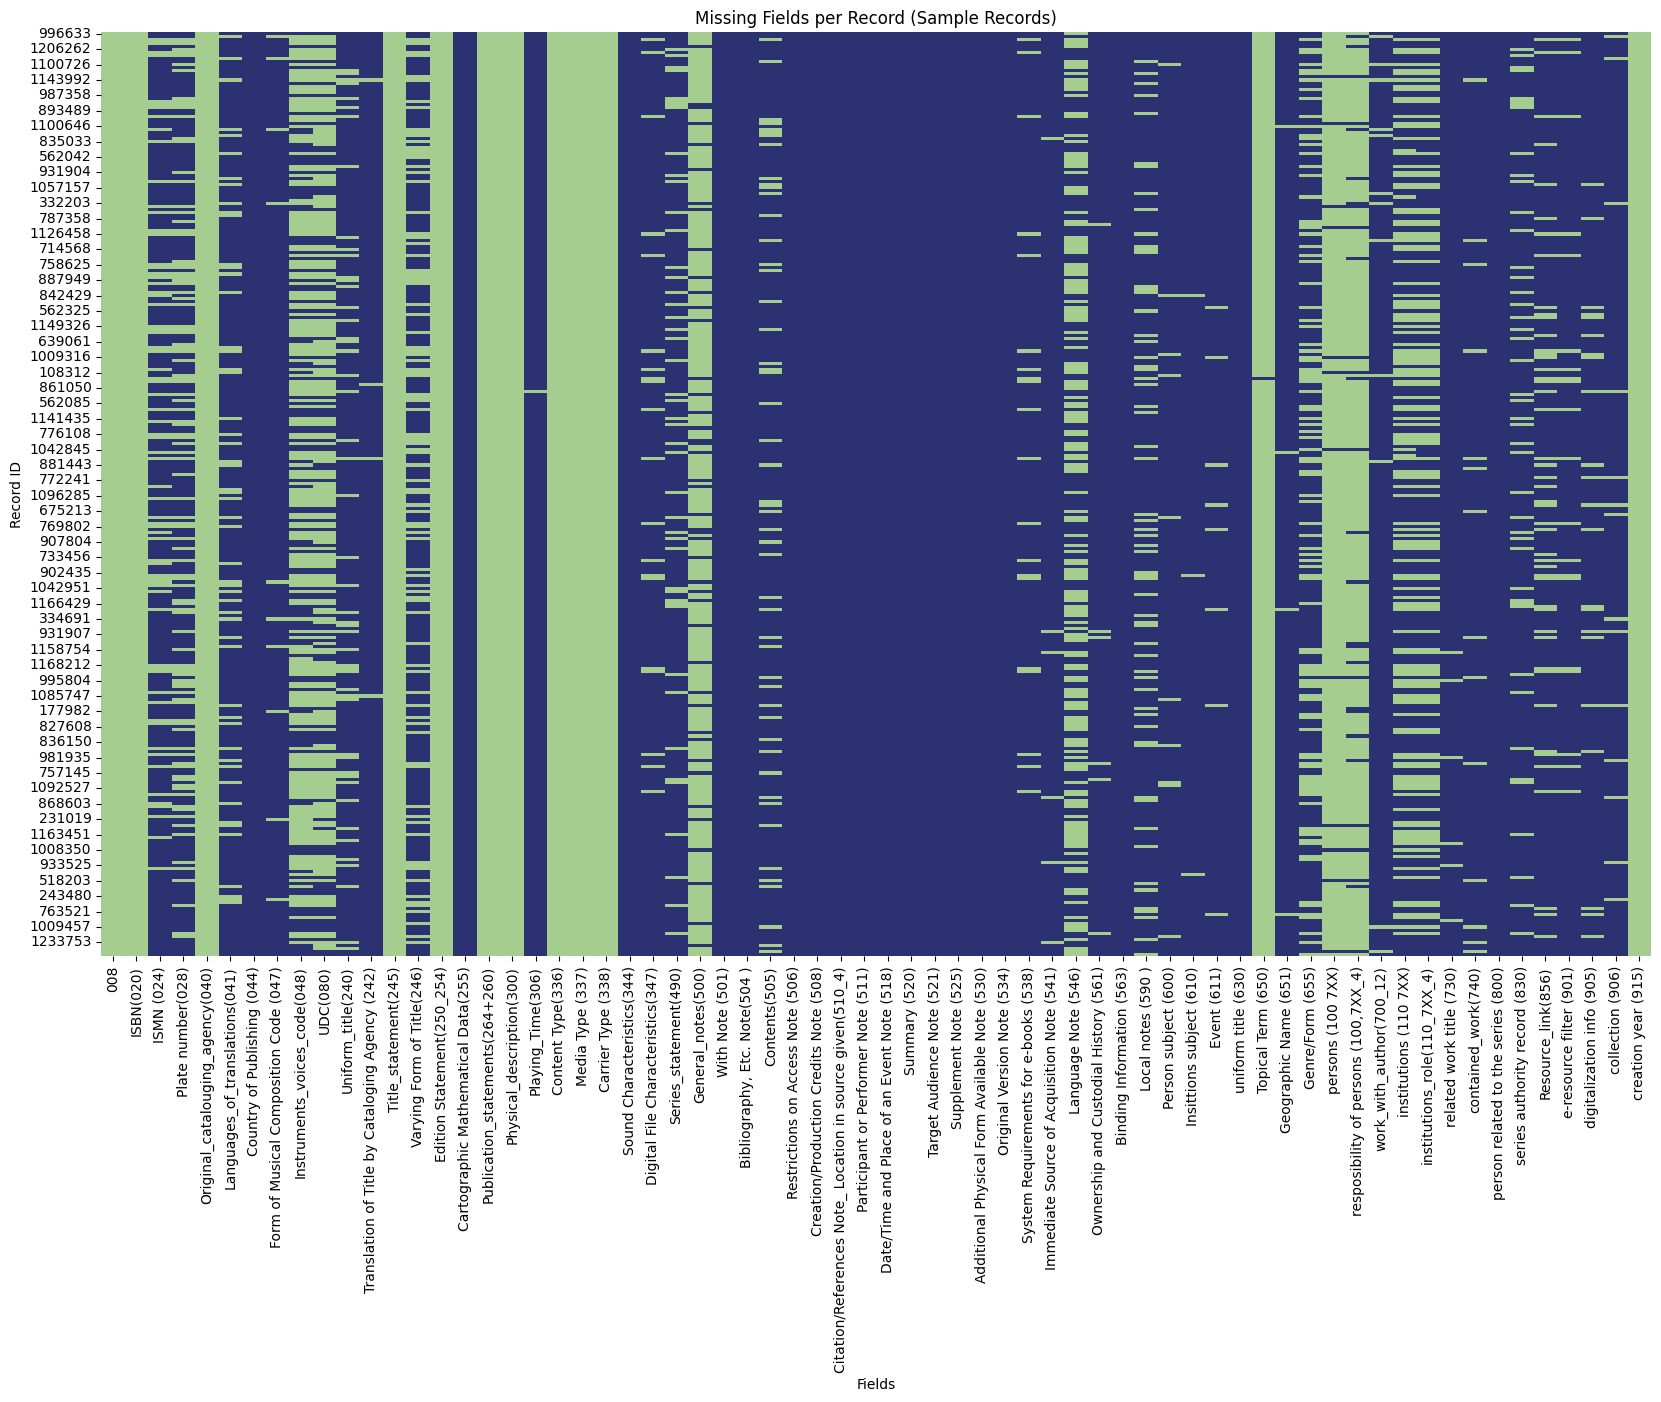

In [167]:
sample = presence_by_record.sample(300, random_state=42)

plt.figure(figsize=(20, 12))
sns.heatmap(~sample, cmap="crest", cbar=False)
plt.title("Missing Fields per Record (Sample Records)")
plt.xlabel("Fields")
plt.ylabel("Record ID")
plt.show()
#plt.savefig("missing_fields_sample_records.png", dpi=200, bbox_inches="tight")
#plt.close()

In [126]:
plt.figure(figsize=(20, 30))
ax = sns.heatmap(
    ~presence_by_record,
    cbar=False,
    rasterized=True
)
plt.title("Missing Fields per Record – All 17 726 Records")
plt.xlabel("Fields")
plt.ylabel("Record ID")

plt.savefig("missing_fields_all_records.png", dpi=200, bbox_inches="tight")
plt.close()

## Resposibilities and Persons

In [127]:
df["persons (100 7XX)"].nunique()

6269

In [128]:
person_counts = (
    df["persons (100 7XX)"]
    .value_counts()
    .reset_index()
)

In [129]:
person_counts.columns = ["person", "count"]

In [130]:
person_counts.head(30)

,person,count
0,"Jāzeps Vītols, 1863-1948",558
1,"Rihards Dubra, 1964-",397
2,"Alfrēds Kalniņš, 1879-1951",395
3,"Ēriks Ešenvalds, 1977-",377
4,"Jānis Rainis, 1865-1929",372
5,"Jēkabs Graubiņš, 1886-1961",329
6,"Arvīds Žilinskis, 1905-1993",320
7,"Emilis Melngailis, 1874-1954",312
8,"Raimonds Pauls, 1936-",309
9,"Valters Kaminskis, 1929-1997",287


In [131]:
fig = px.bar(
    person_counts.head(30),
    x="count",
    y="person",
    orientation="h",
    title="Top 30 Most Frequently Mentioned Persons in Notated Music Records",
    labels={"count": "Number of Records"},
)
fig.update_layout(height=900)
fig.show()

In [132]:
role_counts = (
    df[["persons (100 7XX)", "resposibility of persons (100,7XX_4)"]]
    .value_counts()
    .reset_index(name="count")
)

role_counts.columns = ["person", "role", "count"]

In [133]:
top_n = 50

top_people = (
    role_counts.groupby("person")["count"].sum()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

top_df = role_counts[role_counts["person"].isin(top_people)]

fig = px.bar(
    top_df,
    x="person",
    y="count",
    color="role",
    title="Role Composition of Top Persons",
)
fig.update_layout(xaxis_tickangle=-45, height=700)
fig.show()


## Subjects

In [135]:
subj_counts = (
    df["Topical Term (650)"]
    .dropna()
    .value_counts()
    .reset_index()
)

subj_counts.columns = ["subject", "count"]
subj_counts.head()

,subject,count
0,Kori (jauktie),3651
1,Dziesmas ar klavierēm,3002
2,Latviešu tautasdziesmas,2164
3,Klavieru mūzika,1955
4,Populārā mūzika,1618


In [136]:
subj_counts.nunique()

,0
subject,1264
count,113


In [137]:
fig = px.bar(
    subj_counts.head(30),
    x="count",
    y="subject",
    orientation="h",
    title="Top 30 Subject Terms in Latvian Notated Music Records",
    labels={"count": "Number of records", "subject": "Subject term"}
)
fig.update_layout(height=900)
fig.show()

In [138]:
fig = px.treemap(
    subj_counts.head(50),
    path=["subject"],
    values="count",
    title="Top 50 Most Common Subject Terms (Treemap)"
)
fig.show()

## Data validation

Year from 008 vs Year from 264 $$c

In [149]:
df_unique["full_year_008"] = df_unique["full_year_008"].astype("Int64").astype(str)
df_unique["Date of publication(260_c_un_2641_c)"] = df_unique["Date of publication(260_c_un_2641_c)"].astype(str)

/tmp/ipython-input-2789296747.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-2789296747.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [150]:
df_unique["validated"] = df_unique["full_year_008"] == df_unique["Date of publication(260_c_un_2641_c)"]

/tmp/ipython-input-1234540737.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [151]:
matches = df_unique["validated"].sum()

In [152]:
mismatches = (df_unique["validated"] == False).sum()

In [153]:
missing = df_unique["validated"].isna().sum()

In [154]:
total = len(df_unique)

perc_matches = round(matches / total * 100, 1)
perc_mismatches = round(mismatches / total * 100, 1)
perc_missing = round(missing / total * 100, 1)

In [155]:
print("Total records:", total)
print("Matching years:", matches, f"({perc_matches}%)")
print("Mismatched years:", mismatches, f"({perc_mismatches}%)")
print("Missing values:", missing, f"({perc_missing}%)")


Total records: 17726
Matching years: 12871 (72.6%)
Mismatched years: 4855 (27.4%)
Missing values: 0 (0.0%)


In [156]:
df_mismatch = df_unique[ df_unique["validated"] == False]

df_mismatch[["ID", "full_year_008", "Date of publication(260_c_un_2641_c)"]].head(20)

,ID,full_year_008,Date of publication(260_c_un_2641_c)
201,20774,1999,19--
305,24428,2000,1997-2002
447,45020,1992,199-
797,69620,1993,1993-1994
1174,92571,1994,1995-1996
1248,95362,1995,1996
1431,105613,2007,199-
1518,108458,2007,200-
1548,109089,1997,199-
2178,134787,2007,2006
